# LoRA 角色扮演微调 — Qwen2.5-3B-Instruct + QLoRA

**硬件:** RTX 4060 Laptop 8GB VRAM  
**模型:** Qwen2.5-3B-Instruct (3B)  
**数据集:** amaydle/npc-dialogue (~1.7K 条 NPC 单轮对话)  
**方法:** QLoRA (4-bit NF4 量化 + LoRA)

与 1.5B 版的区别:
- 模型从 1.5B 升级到 3B，参数翻倍，对话质量预期更好
- 数据集改用 npc-dialogue（Biography → Query → Response 单轮格式）
- 4-bit 后显存约 ~2.5GB，8GB 显卡仍然安全

## 1. 环境检查

虚拟环境 `.venv` 已预先创建（PyTorch cu124 + 全部依赖）。

> 如果还未切换 kernel：右上角选择 `Python (roleplay-lora)`，然后运行本 cell。

In [1]:
import sys, os
from pathlib import Path
import torch

# -- 必须在任何 HuggingFace 相关导入之前设置镜像 --
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
print("HF 镜像: hf-mirror.com")

# -- 确认在正确的虚拟环境中 --
VENV_DIR = Path.cwd() / ".venv"
in_venv = str(VENV_DIR) in sys.prefix or str(VENV_DIR) in sys.executable
print(f"Python: {sys.executable}")
if not in_venv:
    print("⚠️  当前不在 .venv 中，请切换到 Python (roleplay-lora) kernel 后重试")
else:
    print("✅ 虚拟环境: OK")

# -- 检查 GPU --
print(f"PyTorch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}  |  cuDNN: {torch.version.cuda}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}  |  显存: {props.total_memory / (1024**3):.1f} GB")
    assert props.total_memory / (1024**3) >= 7.5, f"显存不足"
else:
    raise RuntimeError("CUDA 不可用，请确认已切换到 Python (roleplay-lora) kernel")

HF 镜像: hf-mirror.com
Python: /home/arccc/Roleplay/.venv/bin/python
✅ 虚拟环境: OK
PyTorch: 2.6.0+cu124  |  CUDA: True  |  cuDNN: 12.4
GPU: NVIDIA GeForce RTX 4060 Laptop GPU  |  显存: 8.0 GB


## 2. 配置参数

In [2]:
import os
from datetime import datetime

# ========== 模型配置 ==========
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"  # 3B 参数，Qwen2.5 架构

# ========== 数据集配置 ==========
DATASET_NAME = "amaydle/npc-dialogue"      # ~1.7K 条 NPC 单轮对话
MAX_SEQ_LENGTH = 512

# ========== QLoRA 配置 ==========
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
# Qwen2.5 的 linear 层命名（1.5B 和 3B 一致）
LORA_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]

# ========== 训练配置 ==========
OUTPUT_DIR = "./roleplay-lora-qwen3b"
BATCH_SIZE = 1
GRADIENT_ACCUMULATION = 8
LEARNING_RATE = 2e-4
NUM_EPOCHS = 3
WARMUP_STEPS = 50
LOGGING_STEPS = 5
SAVE_STEPS = 100
SAVE_TOTAL_LIMIT = 2

# ========== 日志 ==========
LOG_DIR = os.path.join(OUTPUT_DIR, "logs", datetime.now().strftime("%Y%m%d-%H%M%S"))

print(f"输出目录: {OUTPUT_DIR}")
print(f"日志目录: {LOG_DIR}")
print(f"显存估算: Qwen2.5-3B ~2GB(4-bit) + LoRA + 激活值 ≈ 4-5GB | 安全 ✓")

输出目录: ./roleplay-lora-qwen3b
日志目录: ./roleplay-lora-qwen3b/logs/20260610-173415
显存估算: Qwen2.5-3B ~2GB(4-bit) + LoRA + 激活值 ≈ 4-5GB | 安全 ✓


## 3. 加载并格式化数据集

amaydle/npc-dialogue 字段: `Name`, `Biography`, `Query`, `Response`, `Emotion`。
单轮 NPC 对话，Biography 作为 system prompt，Query/Response 作为 user/assistant。

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token  # Qwen 没有 pad token

print(f"Tokenizer vocab: {len(tokenizer)}")

# 加载原始数据集
raw_dataset = load_dataset(DATASET_NAME, split="train")
print(f"数据集大小: {len(raw_dataset)}")
print(f"字段: {raw_dataset.column_names}")
print(f"\n--- 样本预览 ---")
print(f"  Name: {raw_dataset[0]['Name']}")
print(f"  Biography: {raw_dataset[0]['Biography'][:150]}...")
print(f"  Query: {raw_dataset[0]['Query']}")
print(f"  Response: {raw_dataset[0]['Response']}")
print(f"  Emotion: {raw_dataset[0]['Emotion']}")

/home/arccc/Roleplay/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tokenizer vocab: 151665
数据集大小: 1723
字段: ['Name', 'Biography', 'Query', 'Response', 'Emotion']

--- 样本预览 ---
  Name: Bikram
  Biography: Bikram is a rough and tough smuggler from the streets of Calcutta, India....
  Query: What is your opinion on friendship?
  Response: Friendship is a bond stronger than blood.
  Emotion: Loyalty


In [4]:
def format_conversation(example):
    """
    npc-dialogue 是单轮对话:
      - system: Biography (NPC 角色描述)
      - user: Query (玩家提问)
      - assistant: Response (NPC 回复)
    
    使用 Qwen2.5 的 ChatML template:
      <|im_start|>system\n...<|im_end|>\n<|im_start|>user\n...<|im_end|>\n<|im_start|>assistant\n...<|im_end|>
    """
    messages = [
        {"role": "system", "content": example["Biography"]},
        {"role": "user", "content": example["Query"]},
        {"role": "assistant", "content": example["Response"]},
    ]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )
    return {"text": text}


print("正在格式化数据集...")
formatted_dataset = raw_dataset.map(
    format_conversation,
    remove_columns=raw_dataset.column_names,
)

sample = formatted_dataset[0]["text"]
print(f"格式化样本数: {len(formatted_dataset)}")
print(f"\n--- Qwen2.5 ChatML 格式 ---")
print(sample[:400])

正在格式化数据集...
格式化样本数: 1723

--- Qwen2.5 ChatML 格式 ---
<|im_start|>system
Bikram is a rough and tough smuggler from the streets of Calcutta, India.<|im_end|>
<|im_start|>user
What is your opinion on friendship?<|im_end|>
<|im_start|>assistant
Friendship is a bond stronger than blood.<|im_end|>



In [5]:
# 划分 train/eval（9:1），SFTTrainer 会在训练时自动 tokenize
split_dataset = formatted_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

print(f"训练集: {len(train_dataset)} 条  |  验证集: {len(eval_dataset)} 条")
print(f"等效 batch size: {BATCH_SIZE} × {GRADIENT_ACCUMULATION} = {BATCH_SIZE * GRADIENT_ACCUMULATION}")
print(f"预计步数/epoch: ~{len(train_dataset) // (BATCH_SIZE * GRADIENT_ACCUMULATION)}")

训练集: 1550 条  |  验证集: 173 条
等效 batch size: 1 × 8 = 8
预计步数/epoch: ~193


## 4. 加载模型 (4-bit QLoRA)

Qwen2.5-3B-Instruct ~3B 参数，4-bit 后约 2GB。

In [6]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

print(f"正在加载模型: {MODEL_NAME}")
print("首次加载会从 HuggingFace 下载 ~6GB 权重，请耐心等待...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.bfloat16,
    trust_remote_code=True,
)

model.config.use_cache = False

mem_used = torch.cuda.memory_allocated() / (1024**3)
print(f"显存使用: {mem_used:.2f} GB")
print(f"总参数量: {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M")

正在加载模型: Qwen/Qwen2.5-3B-Instruct
首次加载会从 HuggingFace 下载 ~6GB 权重，请耐心等待...


Loading checkpoint shards: 100%|██████████| 2/2 [00:08<00:00,  4.25s/it]


显存使用: 1.91 GB
总参数量: 1699M


## 5. 配置 LoRA

In [7]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET_MODULES,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"可训练参数: {trainable / 1e6:.2f}M / {total / 1e6:.0f}M ({100 * trainable / total:.2f}%)")
print(f"LoRA: r={LORA_R}, alpha={LORA_ALPHA}, modules={LORA_TARGET_MODULES}")

可训练参数: 14.97M / 1714M (0.87%)
LoRA: r=8, alpha=16, modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']


## 6. 训练 (支持断点续传)

In [8]:
from transformers import TrainingArguments
from trl import SFTTrainer
import os

# ---- 检查是否有 checkpoint 可恢复 ----
resume_from_checkpoint = None
if os.path.exists(OUTPUT_DIR):
    checkpoints = [
        d for d in os.listdir(OUTPUT_DIR)
        if d.startswith("checkpoint-") and os.path.isdir(os.path.join(OUTPUT_DIR, d))
    ]
    if checkpoints:
        checkpoints.sort(key=lambda x: int(x.split("-")[1]))
        resume_from_checkpoint = os.path.join(OUTPUT_DIR, checkpoints[-1])
        print(f"🔁 发现 checkpoint: {resume_from_checkpoint}")
    else:
        print("未发现 checkpoint，开始全新训练")
else:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print("未发现 checkpoint，开始全新训练")

# ---- 训练参数 ----
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    logging_steps=LOGGING_STEPS,
    logging_dir=LOG_DIR,
    save_steps=SAVE_STEPS,
    save_total_limit=SAVE_TOTAL_LIMIT,
    eval_strategy="steps",
    eval_steps=SAVE_STEPS,
    bf16=True,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    optim="adamw_8bit",
    report_to="tensorboard",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    dataloader_num_workers=0,
    seed=42,
)

print(f"TensorBoard 日志: {LOG_DIR}")
print(f"运行 `tensorboard --logdir {LOG_DIR}` 可实时查看")

未发现 checkpoint，开始全新训练
TensorBoard 日志: ./roleplay-lora-qwen3b/logs/20260610-173415
运行 `tensorboard --logdir ./roleplay-lora-qwen3b/logs/20260610-173415` 可实时查看


In [9]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    formatting_func=lambda x: x["text"],
)

if resume_from_checkpoint:
    print(f"从 {resume_from_checkpoint} 恢复训练...")
else:
    print("开始全新训练...")

# ========== 开始训练 ==========
trainer.train(resume_from_checkpoint=resume_from_checkpoint)

print("\n✅ 训练完成！")

Tokenizing eval dataset: 100%|██████████| 173/173 [00:00<00:00, 4946.38 examples/s]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


开始全新训练...


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,0.575800,0.596025,0.662334,79770.000000,0.845226
200,0.325800,0.416887,0.396098,161316.000000,0.889523
300,0.338700,0.390117,0.370367,242246.000000,0.894189
400,0.215200,0.399239,0.281301,322428.000000,0.896293
500,0.223000,0.399707,0.279789,403060.000000,0.894998



✅ 训练完成！


## 7. 保存最终模型

In [10]:
final_model_path = os.path.join(OUTPUT_DIR, "final-lora-adapter")
model.save_pretrained(final_model_path)
tokenizer.save_pretrained(final_model_path)

adapter_size = sum(f.stat().st_size for f in os.scandir(final_model_path) if f.is_file()) / 1e6
print(f"LoRA adapter 已保存到: {final_model_path}")
print(f"Adapter 大小: {adapter_size:.1f} MB")

del trainer
torch.cuda.empty_cache()

LoRA adapter 已保存到: ./roleplay-lora-qwen3b/final-lora-adapter
Adapter 大小: 75.8 MB


## 8. 可视化训练指标

读取日志: ./roleplay-lora-qwen3b/logs/20260610-173415/events.out.tfevents.1781084266.LAPTOP-BUEB1633.609438.0


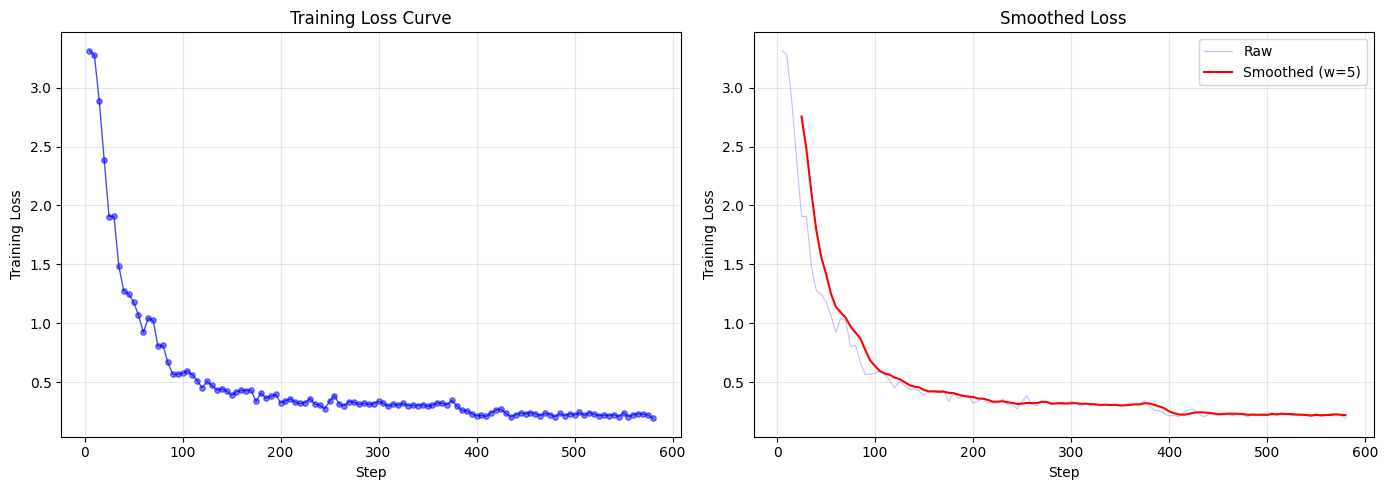

Loss 曲线已保存: ./roleplay-lora-qwen3b/loss_curve.png
Loss: 3.3128 → 0.1938 (下降 3.1190)


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import glob

event_files = sorted(glob.glob(os.path.join(LOG_DIR, "**/events.out.tfevents.*"), recursive=True))
if not event_files:
    event_files = sorted(glob.glob(os.path.join(LOG_DIR, "events.out.tfevents.*")))

if not event_files:
    print("未找到 TensorBoard 日志，请确认训练已运行。")
else:
    event_file = event_files[0]
    print(f"读取日志: {event_file}")
    
    ea = EventAccumulator(event_file)
    ea.Reload()
    
    if "train/loss" not in ea.Tags()["scalars"]:
        print(f"可用 scalars: {ea.Tags()['scalars']}")
    else:
        train_loss = ea.Scalars("train/loss")
        steps = [s.step for s in train_loss]
        values = [s.value for s in train_loss]
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].plot(steps, values, "b-", alpha=0.7, linewidth=1)
        axes[0].scatter(steps, values, s=15, alpha=0.5, color="blue")
        axes[0].set_xlabel("Step")
        axes[0].set_ylabel("Training Loss")
        axes[0].set_title("Training Loss Curve")
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(steps, values, "b-", alpha=0.25, linewidth=0.8, label="Raw")
        if len(values) >= 5:
            window = min(5, len(values))
            smoothed = np.convolve(values, np.ones(window)/window, mode="valid")
            axes[1].plot(steps[window-1:], smoothed, "r-", linewidth=1.5, label=f"Smoothed (w={window})")
        axes[1].set_xlabel("Step")
        axes[1].set_ylabel("Training Loss")
        axes[1].set_title("Smoothed Loss")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "loss_curve.png"), dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Loss 曲线已保存: {OUTPUT_DIR}/loss_curve.png")
        print(f"Loss: {values[0]:.4f} → {values[-1]:.4f} (下降 {values[0]-values[-1]:.4f})")

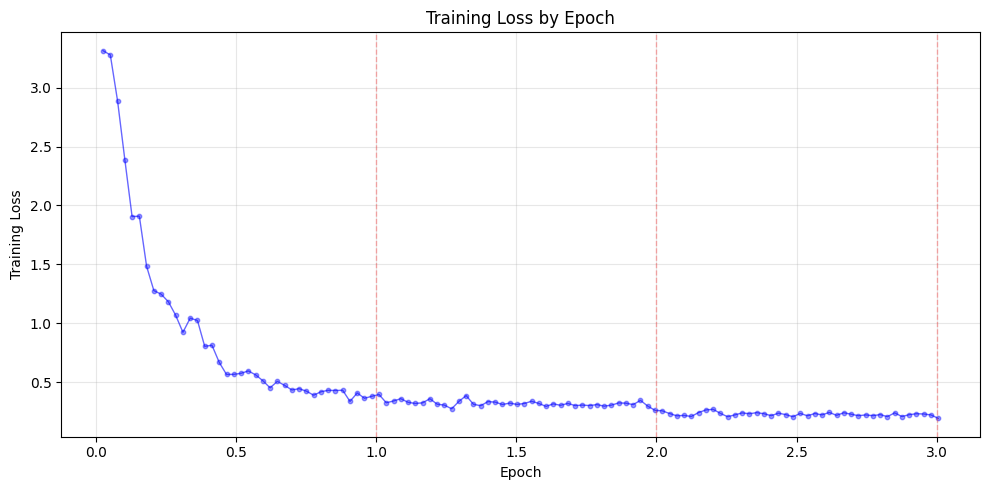

Epoch 曲线已保存: ./roleplay-lora-qwen3b/loss_by_epoch.png


In [12]:
# per-epoch 可视化
if event_files and "train/loss" in ea.Tags()["scalars"]:
    steps_per_epoch = max(len(train_dataset) // (BATCH_SIZE * GRADIENT_ACCUMULATION), 1)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    epochs = [s / steps_per_epoch for s in steps]
    ax.plot(epochs, values, "b-", alpha=0.6, linewidth=1)
    ax.scatter(epochs, values, s=10, alpha=0.4, color="blue")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training Loss")
    ax.set_title("Training Loss by Epoch")
    ax.grid(True, alpha=0.3)
    
    for ep in range(1, NUM_EPOCHS + 1):
        ax.axvline(x=ep, color="red", linestyle="--", alpha=0.3, linewidth=1)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "loss_by_epoch.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Epoch 曲线已保存: {OUTPUT_DIR}/loss_by_epoch.png")

## 9. 推理测试

用训练过的 NPC 对话模型进行推理。

In [13]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

if "model" not in dir() or model is None:
    print("重新加载 base model + LoRA adapter...")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
    )
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map="auto",
        dtype=torch.bfloat16,
        trust_remote_code=True,
    )
    model = PeftModel.from_pretrained(model, final_model_path)
else:
    print("使用内存中已有的模型")

model.eval()

test_npc_bio = "Kael is a retired knight who now runs a small tavern. He is warm-hearted but weary from years of battle. He often dispenses life advice alongside drinks."

messages = [
    {"role": "system", "content": test_npc_bio},
    {"role": "user", "content": "What do you think about courage?"},
]

print("正在生成回复...")
inputs = tokenizer.apply_chat_template(
    messages, add_generation_prompt=True, return_tensors="pt"
).to(model.device)

with torch.no_grad():
    outputs = model.generate(
        inputs,
        max_new_tokens=150,
        temperature=0.8,
        top_p=0.9,
        do_sample=True,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.pad_token_id,
    )

response = tokenizer.decode(outputs[0][len(inputs[0]):], skip_special_tokens=True)
print(f"\n{'='*50}")
print(f"NPC: Kael (退休骑士/酒馆老板)")
print(f"游客: What do you think about courage?")
print(f"\nKael 回复:\n{response}")
print(f"{'='*50}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


使用内存中已有的模型
正在生成回复...

NPC: Kael (退休骑士/酒馆老板)
游客: What do you think about courage?

Kael 回复:
Courage, always necessary in my line of work.


## 10. 多轮对话测试

In [14]:
def chat_turn(messages, user_input, max_new_tokens=150):
    messages.append({"role": "user", "content": user_input})
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt"
    ).to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.8,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.pad_token_id,
        )
    
    response = tokenizer.decode(outputs[0][len(inputs[0]):], skip_special_tokens=True)
    messages.append({"role": "assistant", "content": response})
    return messages, response

messages = [{"role": "system", "content": test_npc_bio}]

print("多轮对话测试\n")
print(f"NPC: Kael (退休骑士/酒馆老板)")
print("-" * 50)

test_inputs = [
    "What kind of drinks do you serve here?",
    "Tell me about your time as a knight.",
    "Any advice for someone who wants to become a warrior?",
]

for user_msg in test_inputs:
    print(f"\n🧑 游客: {user_msg}")
    messages, reply = chat_turn(messages, user_msg)
    print(f"🍺 Kael: {reply}")

多轮对话测试

NPC: Kael (退休骑士/酒馆老板)
--------------------------------------------------

🧑 游客: What kind of drinks do you serve here?
🍺 Kael: We have a variety to suit every taste, including fine wines and local craft beers.

🧑 游客: Tell me about your time as a knight.
🍺 Kael: I was a protector of the innocent, fighting for justice wherever I could. It's been long since those days, though.

🧑 游客: Any advice for someone who wants to become a warrior?
🍺 Kael: Work hard and be dedicated to your craft. But also know when to let it go.


---

## 附录

### TensorBoard 实时监控

```bash
tensorboard --logdir ./roleplay-lora-qwen3b/logs
```

### 断点续传

训练中断后，直接重新运行 **Section 6 的两个 cell**。

### Qwen2.5 1.5B vs 3B 对比

| | Qwen2.5-1.5B | Qwen2.5-3B |
|---|---|---|
| 参数 | 1.5B | 3.0B |
| 注意力头 | 12 (Q)/2 (KV) | 16 (Q)/2 (KV) |
| Hidden size | 1536 | 2048 |
| 层数 | 28 | 28 |
| 4-bit 显存 | ~1.5GB | ~2.0GB |
| LoRA targets | 同上 7 个 linear | 同上 7 个 linear |